# L2 · Why we need hidden layers: XOR

**One idea:** a linear classifier (logistic regression) cannot solve XOR, but a
one-hidden-layer MLP with a nonlinearity can — depth + activation buy us
**nonlinear decision boundaries**. We use the same exact, constructed
two-hidden-unit network as the lecture deck; it is not a training result.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
np.random.seed(0)
torch.manual_seed(0)

# XOR dataset
X = torch.tensor([[0.,0.],[0.,1.],[1.,0.],[1.,1.]])
y = torch.tensor([[0.],[1.],[1.],[0.]])

## 1. A single linear layer (logistic regression) cannot separate XOR

In [2]:
def train(model, steps=3000, lr=0.1):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    lossf = nn.BCEWithLogitsLoss()
    for _ in range(steps):
        opt.zero_grad()
        loss = lossf(model(X), y)
        loss.backward()
        opt.step()
    with torch.no_grad():
        acc = ((torch.sigmoid(model(X)) > 0.5).float() == y).float().mean().item()
    return acc

linear = nn.Linear(2, 1)
acc_lin = train(linear)
print(f"linear model accuracy on XOR: {acc_lin:.2f}")

linear model accuracy on XOR: 0.50


## 2. The deck's exact two-hidden-unit ReLU MLP solves all four cases

**Evidence label — constructed + computed:** the weights below are chosen
analytically, then the four logits and predictions are computed.

In [3]:
exact_mlp = nn.Sequential(nn.Linear(2, 2), nn.ReLU(), nn.Linear(2, 1))
with torch.no_grad():
    # h1 = ReLU(x1 + x2), h2 = ReLU(x1 + x2 - 1)
    exact_mlp[0].weight.copy_(torch.tensor([[1., 1.], [1., 1.]]))
    exact_mlp[0].bias.copy_(torch.tensor([0., -1.]))
    # z = 2 h1 - 4 h2 - 1
    exact_mlp[2].weight.copy_(torch.tensor([[2., -4.]]))
    exact_mlp[2].bias.copy_(torch.tensor([-1.]))

with torch.no_grad():
    hidden = exact_mlp[1](exact_mlp[0](X))
    logits = exact_mlp(X)
    predictions = (logits >= 0).float()
    acc_exact = (predictions == y).float().mean().item()

print("rows: x1 x2 | h1 h2 | logit | prediction | target")
print(torch.cat([X, hidden, logits, predictions, y], dim=1))
print(f"constructed exact MLP accuracy on XOR: {acc_exact:.2f}")
assert acc_exact == 1.0

rows: x1 x2 | h1 h2 | logit | prediction | target
tensor([[ 0.,  0.,  0.,  0., -1.,  0.,  0.],
        [ 0.,  1.,  1.,  0.,  1.,  1.,  1.],
        [ 1.,  0.,  1.,  0.,  1.,  1.,  1.],
        [ 1.,  1.,  2.,  1., -1.,  0.,  0.]])
constructed exact MLP accuracy on XOR: 1.00


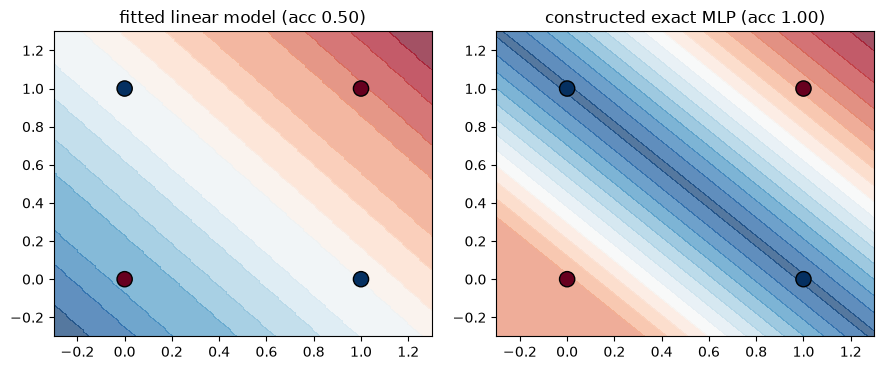

In [4]:
# decision boundaries
gx, gy = np.meshgrid(np.linspace(-0.3, 1.3, 200), np.linspace(-0.3, 1.3, 200))
grid = torch.tensor(np.column_stack([gx.ravel(), gy.ravel()]), dtype=torch.float32)

fig, ax = plt.subplots(1, 2, figsize=(9, 3.8))
for a, model, name in [(ax[0], linear, f"fitted linear model (acc {acc_lin:.2f})"),
                       (ax[1], exact_mlp, f"constructed exact MLP (acc {acc_exact:.2f})")]:
    with torch.no_grad():
        prob = torch.sigmoid(model(grid)).numpy().reshape(gx.shape)
    a.contourf(gx, gy, prob, levels=20, cmap="RdBu", alpha=0.7)
    a.scatter(X[:,0], X[:,1], c=y.ravel(), cmap="RdBu", edgecolors="k", s=120)
    a.set_title(name)
plt.tight_layout(); plt.show()

## Takeaway
- Logistic/softmax regression only draw **linear** boundaries — XOR is impossible for them.
- The exact two-unit network computes $h_1=\mathrm{ReLU}(x_1+x_2)$,
  $h_2=\mathrm{ReLU}(x_1+x_2-1)$, and $z=2h_1-4h_2-1$, matching the deck.
- One hidden layer + a nonlinearity **creates a representation** in which the
  classes become separable. This construction proves representational capacity;
  it does not claim that an optimizer found these weights.